In [2]:
# --------------------------------------------------------------------------------
# Trait Enrichment and Significance Analysis for Clusters using scDRS
# --------------------------------------------------------------------------------
# Description:
# This script performs enrichment and significance analysis for various disease traits
# across defined clusters using scDRS results. The analysis involves:
# 1. Loading disease trait enrichment data for each cluster from summary files.
# 2. Extracting enrichment scores and significance values for each trait.
# 3. Visualizing the enrichment patterns with a heatmap, where cells are annotated 
#    to indicate statistically significant traits.

# Analysis Goals:
# - Identify disease traits significantly enriched in specific clusters.
# - Provide insight into the relationship between clusters and trait-specific 
#   activation patterns, revealing potential disease-related cluster characteristics.


In [3]:

# --------------------------------------------------------------------------------
# Import necessary libraries
# --------------------------------------------------------------------------------
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import scipy
# --------------------------------------------------------------------------------
# Set working directory
# --------------------------------------------------------------------------------
# Set the working directory to the folder containing trait summary files.
os.chdir('2024_04_01_scDRS/traits/summary/')
save_Fig_dir = 'Figures/Figure3/'
save_Sup_Fig_dir = 'SFigures/SFigure3/'


In [4]:
# --------------------------------------------------------------------------------
# Define the trait files to load
# --------------------------------------------------------------------------------
# Define the list of disease traits (only stroke-related traits) to analyze.
# Use this list to generate the corresponding summary file names.
stroke_columns = ['ich',
 'ich_deep',
 'ich_lobar',
 'stroke',
 'stroke_ce',
 'stroke_lvd',
 'stroke_svd']

files = [f"Metacells_identity_{trait}_summary.csv" for trait in stroke_columns]

# --------------------------------------------------------------------------------
# Initialize lists to store data tables and trait names
# --------------------------------------------------------------------------------
tbls = []  # List to store each trait's data table.
nms = []   # List to store each trait's name for labeling.


In [5]:
# --------------------------------------------------------------------------------
# Load each trait file and extract the enrichment table
# --------------------------------------------------------------------------------
for file in files:
    # Open each summary file and read it as a table, skipping bad lines if any.
    f = open(file, 'r')
    tble = pd.read_table(f, sep='\t', on_bad_lines='skip')
    
    # Extract and clean the trait name from the file name for labeling.
    name = file.replace('Metacells_identity_', '').replace('_summary.csv', '')
    
    # Append the table and name to the respective lists.
    tbls.append(tble)
    nms.append(name)

In [6]:
# --------------------------------------------------------------------------------
# Create a DataFrame of enrichment scores for each trait
# --------------------------------------------------------------------------------
# Extract the enrichment score column 'assoc_mcz' from each table and combine them.
df = pd.concat([tble['group']] + [tble['assoc_mcz'] for tble in tbls[:]], axis=1)
df = df.set_index(df.columns[0])  # Set the 'group' column as the index.
df.columns = nms                 # Set column names to trait names.
df02 = df.copy()                 # Make a copy for further analysis.


# --------------------------------------------------------------------------------
# Create a DataFrame of significance values for each trait
# --------------------------------------------------------------------------------
# Extract the significance value column 'assoc_mcp' from each table and combine them.
df = pd.concat([tble['group']] + [tble['assoc_mcp'] for tble in tbls[:]], axis=1)
df = df.set_index(df.columns[0])  # Set the 'group' column as the index.
df.columns = nms                 # Set column names to trait names.
df02b = df.copy()                # Make another copy for significance annotation.



In [7]:
# --------------------------------------------------------------------------------
# Annotate cells based on significance (p-value <= 0.05)
# --------------------------------------------------------------------------------
# Replace significant p-values (<= 0.05) with '*' and others with an empty string.
df02b = df02b.apply(lambda x: ['*' if y <= 0.05 else '' for y in x])

/Users/dimitrioskyriakis/Library/Python/3.9/lib/python/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/dimitrioskyriakis/Documents/Projects/Myeloid_ICH/Figures/Figure3/2024_12_Figure_2E.pdf'

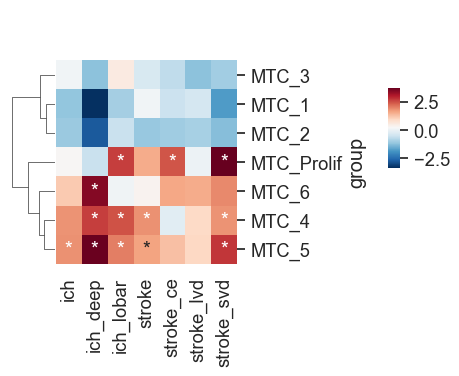

In [8]:
# --------------------------------------------------------------------------------
# Configure visualization settings and create a heatmap
# --------------------------------------------------------------------------------
sns.set(font_scale=1.2)  # Set font scale for the heatmap.

# Create a cluster map for the enrichment scores (df02), with annotated significance.
ax = sns.clustermap(df02, metric="euclidean", square=True, figsize=(4, 4),
                    col_cluster=False,row_cluster=True, yticklabels=True, cmap='RdBu_r', 
                    annot=df02b, fmt='', cbar_pos=(1, 0.55, 0.03, 0.2))

# Rotate x-axis labels for readability.
plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90)
ax.savefig(save_Fig_dir + "2024_12_Figure_2E.pdf")
ax.savefig(save_Fig_dir + "2024_12_Figure_2E.png")


# SUP FIGURE 3 C

In [22]:
# --------------------------------------------------------------------------------
# Define the trait files to load
# --------------------------------------------------------------------------------
# Define the list of disease traits (only stroke-related traits) to analyze.
# Use this list to generate the corresponding summary file names.
alz_columns = ['alz2','alz2noapoe','alzWightman','alz','alzKunkle']
scz_columns = ['sz3','sz_mvp','sz','sa_mdd_bip_scz','sz_eur']
mdd_columns = ['sa_mdd','mdd','mdd2','mdd_ipsych']
asd_columns = ['adhd_or_asd','asd','asd_vs_adhd']
pd_columns = ['pd','pd_without_23andME']
ms_columns = ['ms']
bd_columns = ['ibd']


In [23]:
Not_stroke = alz_columns +scz_columns + mdd_columns+ asd_columns+pd_columns+ms_columns+bd_columns


files=[f"Metacells_identity_{trait}_summary.csv" for trait in Not_stroke]
tbls = []
nms = []
for file in files:
    f=open(file, 'r')
    tble = pd.read_table(f, sep='\t', on_bad_lines='skip') 
    name=file.replace('Metacells_identity_','')
    name=name.replace('_summary.csv','')
    tbls.append(tble)
    nms.append(name)

df = pd.concat([tble['group']] + [tble['assoc_mcz'] for tble in tbls[:]], axis = 1)
df=df.set_index(df.columns[0])
df.columns=nms
df = df.sort_index(axis=1)


/Users/dimitrioskyriakis/Library/Python/3.9/lib/python/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


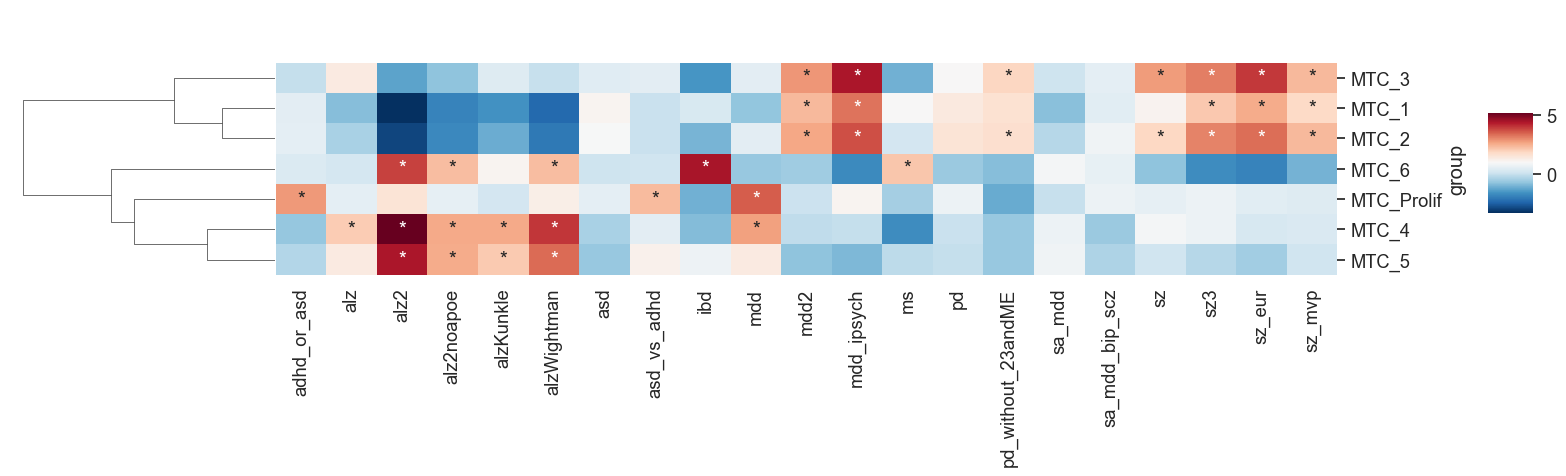

In [24]:


df02=df.copy()

df = pd.concat([tble['group']] + [tble['assoc_mcp'] for tble in tbls[:]], axis = 1)
df=df.set_index(df.columns[0])
df.columns=nms
df = df.sort_index(axis=1)

# df.columns= df.columns.str.split('_').str[0]

df02b=df.copy()
#df=-np.log(df)
df02b=df02b.astype('category')

df02b = df02b.apply(lambda x: ['*' if y <= 0.05 else '' for y in x])


import matplotlib
# matplotlib.use('TkAgg')

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# df02 = df02.sort_index(axis=1)

sns.set(font_scale=1.2)
ax=sns.clustermap(df02,metric="euclidean", 
                square=True,figsize=(15, 5),col_cluster=False,row_cluster=True,
               yticklabels=True, cmap='RdBu_r',annot=df02b, fmt = '',
               cbar_pos=(1, 0.55, 0.03, 0.2))  # Adjust the values as needed)
plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90) 

ax.savefig(save_Sup_Fig_dir+"2024_12_Sup.Fig_3C.pdf")
ax.savefig(save_Sup_Fig_dir+"2024_12_Sup.Fig_3C.png")


/Users/dimitrioskyriakis/Library/Python/3.9/lib/python/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


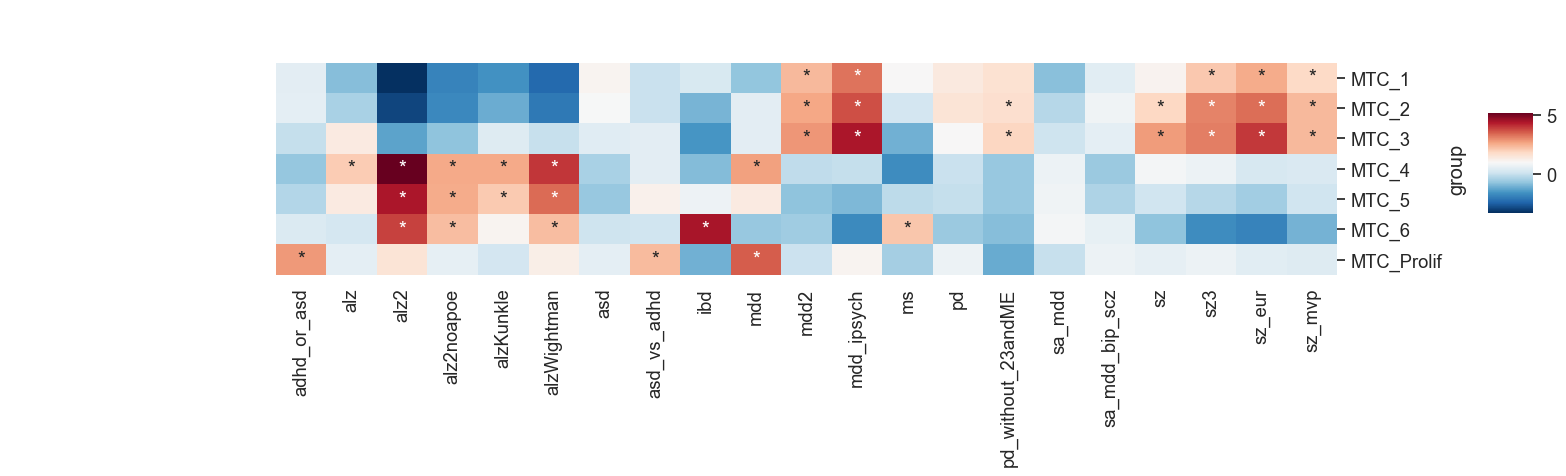

In [25]:
sns.set(font_scale=1.2)
ax=sns.clustermap(df02,metric="euclidean", 
                square=True,figsize=(15, 5),col_cluster=False,row_cluster=False,
               yticklabels=True, cmap='RdBu_r',annot=df02b, fmt = '',
               cbar_pos=(1, 0.55, 0.03, 0.2))  # Adjust the values as needed)
plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=90) 

ax.savefig(save_Sup_Fig_dir+"2024_12_Sup.Fig_3C_unord.pdf")
ax.savefig(save_Sup_Fig_dir+"2024_12_Sup.Fig_3C_unord.png")